In [ ]:
import os
import numpy as np
from PIL import Image
TRAIN_DIR ="/kaggle/input/datasets/salader/dogsvscats/train"
IMG_SIZE = (32, 32)
SAMPLE_SIZE = 200 # per class

def load_images(folder, label, n):
    files = os.listdir(folder)[:n]
    data, labels = [], []
    for fname in files:
       img = Image.open(os.path.join(folder, fname)).convert("RGB").resize(IMG_SIZE)
       data.append(np.array(img)); labels.append(label)
       return data, labels
cat_imgs, cat_labels = load_images(os.path.join(TRAIN_DIR, "cats"), "cat", SAMPLE_SIZE)
dog_imgs, dog_labels = load_images(os.path.join(TRAIN_DIR, "dogs"), "dog", SAMPLE_SIZE)
images = np.array(cat_imgs + dog_imgs)
true_labels = cat_labels + dog_labels
print(images.shape)

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(images), figsize=(4, 2))

for i in range(len(images)):
    axes[i].imshow(images[i])
    axes[i].set_title(true_labels[i])
    axes[i].axis("off")

plt.show()

In [ ]:
import os
import numpy as np
from PIL import Image

TRAIN_DIR = "/kaggle/input/datasets/salader/dogsvscats/train"
IMG_SIZE = (32, 32)
SAMPLE_SIZE = 200

def load_images(folder, label, n):
    files = os.listdir(folder)[:n]
    data = []
    labels = []

    for fname in files:
        try:
            img = Image.open(os.path.join(folder, fname)).convert("RGB")
            img = img.resize(IMG_SIZE)
            data.append(np.array(img))
            labels.append(label)
        except:
            continue

    return data, labels

cat_imgs, cat_labels = load_images(
    os.path.join(TRAIN_DIR, "cats"), "cat", SAMPLE_SIZE
)

dog_imgs, dog_labels = load_images(
    os.path.join(TRAIN_DIR, "dogs"), "dog", SAMPLE_SIZE
)

images = np.array(cat_imgs + dog_imgs)
true_labels = cat_labels + dog_labels

print("Image data shape:", images.shape)
print("Number of labels:", len(true_labels))

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 6, figsize=(12, 2))
for i in range(6):
    axes[i].imshow(images[i * 65])
    axes[i].set_title(true_labels[i * 65])
    axes[i].axis("off")
plt.show()

In [ ]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

TRAIN_DIR = "/kaggle/input/datasets/salader/dogsvscats/train"
IMG_SIZE = (32, 32)
SAMPLE_SIZE = 200

def load_images(folder, label, n):
    files = os.listdir(folder)[:n]
    
    data = []
    display_images = []
    labels = []

    for fname in files:
        try:
            # Original image for displaying
            original_img = Image.open(
                os.path.join(folder, fname)
            ).convert("RGB")
            
            display_images.append(np.array(original_img))

            # Small image for clustering
            small_img = original_img.resize(IMG_SIZE)
            
            data.append(np.array(small_img))
            labels.append(label)

        except:
            continue

    return data, display_images, labels


cat_imgs, cat_display, cat_labels = load_images(
    os.path.join(TRAIN_DIR, "cats"),
    "cat",
    SAMPLE_SIZE
)

dog_imgs, dog_display, dog_labels = load_images(
    os.path.join(TRAIN_DIR, "dogs"),
    "dog",
    SAMPLE_SIZE
)

# 32x32 images used for clustering
images = np.array(cat_imgs + dog_imgs)

# Original images used only for visualization
display_images = cat_display + dog_display

true_labels = cat_labels + dog_labels

print("Clustering images:", images.shape)
print("Display images:", len(display_images))

In [ ]:
fig, axes = plt.subplots(1, 9, figsize=(15, 4))

indices = np.linspace(0, len(display_images) - 1, 9, dtype=int)

for i, idx in enumerate(indices):
    axes[i].imshow(display_images[idx])
    axes[i].set_title(true_labels[idx])
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
X = images.reshape(len(images), -1) / 255.0

print(X.shape)

In [ ]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X)

In [ ]:
predicted_clusters = kmeans.predict(X)
import pandas as pd
print(pd.Series(predicted_clusters).value_counts())

In [ ]:
comparison = pd.crosstab(predicted_clusters, true_labels)
print(comparison)

In [ ]:
print("Total images:", len(images))
print("Cats:", true_labels.count("cat"))
print("Dogs:", true_labels.count("dog"))

In [ ]:
comparison = pd.crosstab(
    predicted_clusters,
    true_labels
)

print(comparison)

In [ ]:
# Calculate clustering accuracy
cluster_0 = comparison.loc[0]
cluster_1 = comparison.loc[1]

accuracy_1 = (
    cluster_0["cat"] + cluster_1["dog"]
) / len(true_labels)

accuracy_2 = (
    cluster_0["dog"] + cluster_1["cat"]
) / len(true_labels)

accuracy = max(accuracy_1, accuracy_2)

print(f"Clustering Accuracy: {accuracy:.2%}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

cluster_0_indices = np.where(predicted_clusters == 0)[0]

selected_0 = np.random.choice(
    cluster_0_indices,
    size=min(10, len(cluster_0_indices)),
    replace=False
)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for i, idx in enumerate(selected_0):
    axes.flat[i].imshow(display_images[idx])
    axes.flat[i].set_title(
        f"True: {true_labels[idx]}"
    )
    axes.flat[i].axis("off")

plt.suptitle("Cluster 0", fontsize=18)
plt.tight_layout()
plt.show()

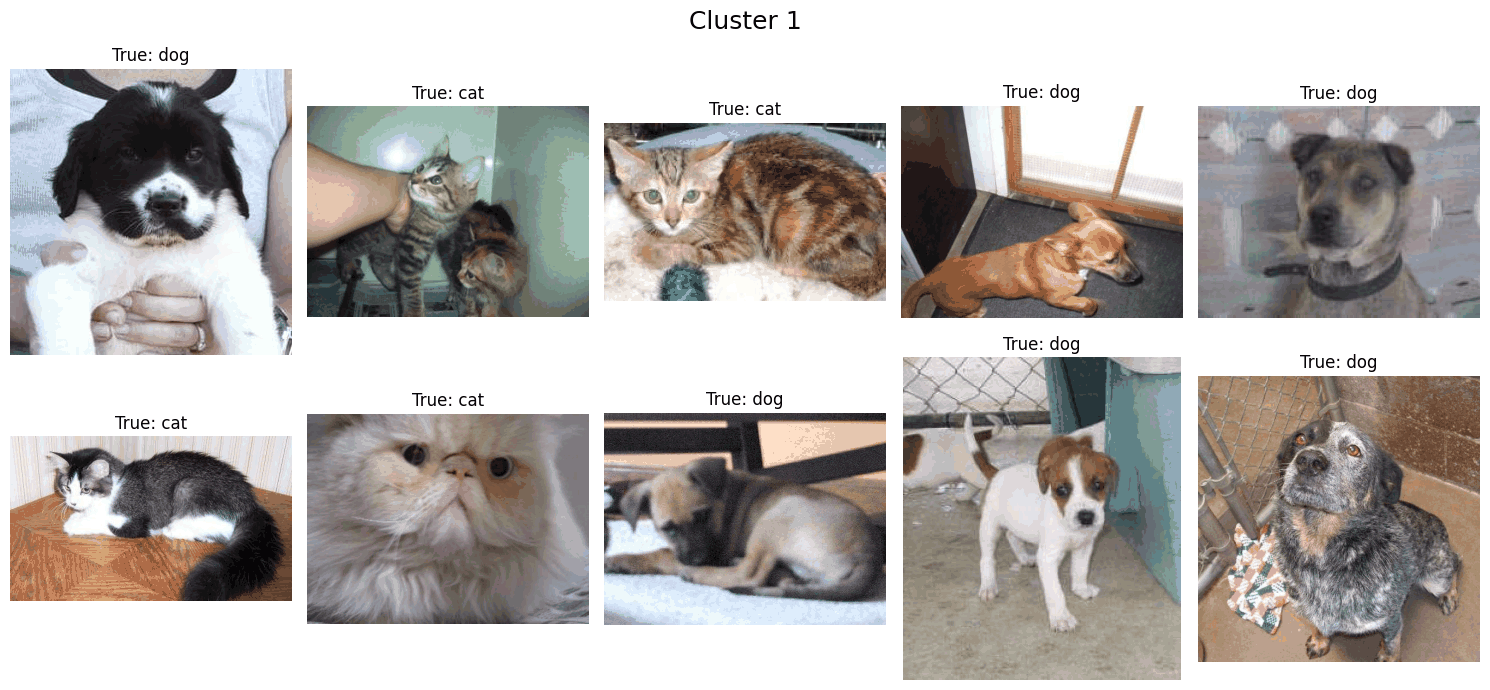

In [15]:
cluster_1_indices = np.where(predicted_clusters == 1)[0]

selected_1 = np.random.choice(
    cluster_1_indices,
    size=min(10, len(cluster_1_indices)),
    replace=False
)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))

for i, idx in enumerate(selected_1):
    axes.flat[i].imshow(display_images[idx])
    axes.flat[i].set_title(
        f"True: {true_labels[idx]}"
    )
    axes.flat[i].axis("off")

plt.suptitle("Cluster 1", fontsize=18)
plt.tight_layout()
plt.show()